# Stage 25 — Experiment B: Progressive Level Pruning

Trains `ProtoSegNet(proto_levels=[1,2,3,4], use_level_attention=True)` with
progressive soft-pruning of low-attention levels during Phase B.

**Hypothesis (RQ7):** Automatically detaching and freezing levels whose attention
weight stays below threshold fully relieves the encoder of those levels' gradient,
converging to a functionally M2-equivalent architecture without prior knowledge
of which levels to remove.

**Key difference from M4-attn noent:**
At each validation epoch (≥ PRUNE_START_EPOCH), if a level's attention weight
has stayed below PRUNE_THRESHOLD for PRUNE_PATIENCE consecutive val epochs,
`model.prune_level(l)` is called — detaching its encoder features and freezing
its PrototypeLayer. The decoder skip connection still carries its frozen features.

Pruning config (from v5 attention evolution):
- PRUNE_THRESHOLD = 0.05  (w_L1/L2 < 0.01 from ep 40 onward in noent run)
- PRUNE_PATIENCE  = 5 val epochs = 25 training epochs
- PRUNE_START_EPOCH = 40  (let attention stabilise after unfreeze at ep 31)

Expected: L1 and L2 auto-pruned around ep 42–45, leaving active {L3, L4} ≡ M2.

Baselines:
- **M4-attn noent**: 3D Dice 0.8416, Purity L4 0.537, AP L4 0.085
- **M4-attn wloss**: 3D Dice 0.8475, Purity L4 0.697, AP L4 0.195  ← Exp A
- **M2 (max)**:      3D Dice 0.8722, Purity L4 0.804, AP L4 0.236  ← ceiling

## 0. Config

In [1]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# ── Model config ──────────────────────────────────────────────────────────────
PROTO_LEVELS = [1, 2, 3, 4]
USE_LEVEL_ATTENTION = True
MODALITY = "ct"
SUFFIX = "_l1234_attn_pruned"

# ── Pruning config ────────────────────────────────────────────────────────────
PRUNE_THRESHOLD = 0.05  # attention weight below this triggers pruning countdown
PRUNE_PATIENCE = 3  # must stay below threshold for this many val epochs
PRUNE_START_EPOCH = 40  # earliest epoch pruning can trigger

# ── Resume ────────────────────────────────────────────────────────────────────
RESUME = False  # set False to train from scratch

# ── Training hyperparameters (same as noent baseline) ────────────────────────
LAMBDA_ENT = 0.0
ATTN_WARMUP_EPOCHS = 10
LAMBDA_DIV = 0.001
LAMBDA_PUSH = 0.5
LAMBDA_PULL = 0.25
BATCH_SIZE = 16
LR = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END = 20
PHASE_B_END = 80
PHASE_C_END = 100
VAL_EVERY = 5
PATIENCE = 15
PROJ_INTERVAL = 10

DATA_DIR = "data/pack/processed_data"
CKPT_DIR = "checkpoints"
LOG_DIR = "results/v6"

import pathlib

pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH = f"{CKPT_DIR}/proto_seg_{MODALITY}{SUFFIX}.pth"
PROJ_PATH = f"{CKPT_DIR}/projected_prototypes_{MODALITY}{SUFFIX}.pt"
LOG_PATH = f"{LOG_DIR}/train_curve_proto_{MODALITY}{SUFFIX}.csv"
ATTN_LOG = f"{LOG_DIR}/attention_weight_evolution{SUFFIX}.csv"
PRUNE_LOG = f"{LOG_DIR}/pruning_log.csv"

print(f"proto_levels      : {PROTO_LEVELS}")
print(f"prune_threshold   : {PRUNE_THRESHOLD}")
print(f"prune_patience    : {PRUNE_PATIENCE} val epochs")
print(f"prune_start_epoch : {PRUNE_START_EPOCH}")
print(f"resume            : {RESUME}")
print(f"checkpoint        : {CKPT_PATH}")

proto_levels      : [1, 2, 3, 4]
prune_threshold   : 0.05
prune_patience    : 3 val epochs
prune_start_epoch : 40
resume            : False
checkpoint        : checkpoints/proto_seg_ct_l1234_attn_pruned.pth


## 1. Imports & Setup

In [2]:
import csv, time
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import ProtoSegLoss
from src.metrics.dice import dice_per_class, mean_foreground_dice

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {DEVICE}")

Device: mps


## 2. Data & Model

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(
    f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  "
    f"Test: {len(loaders['test'].dataset)}"
)

weights_path = f"data/class_weights_{MODALITY}.pt"
if pathlib.Path(weights_path).exists():
    class_weights = torch.load(weights_path, weights_only=True)
else:
    class_weights = compute_class_weights(DATA_DIR, MODALITY)
    torch.save(class_weights, weights_path)

model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

print(f"proto_levels    : {model.proto_levels}")
print(f"pruned_levels   : {model.pruned_levels}  (starts empty)")
print(f"level_attention : {model.level_attention}")
print(f"Total params    : {model.count_parameters()['total']:,}")

seg_loss = SegmentationLoss(
    class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES
)
criterion = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)

Train: 3389  Val: 382  Test: 484
proto_levels    : [1, 2, 3, 4]
pruned_levels   : set()  (starts empty)
level_attention : LevelAttentionModule(
  (mlp): Sequential(
    (0): Linear(in_features=480, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)
Total params    : 2,587,308


## 3. Helpers

In [4]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


@torch.no_grad()
def mean_attention_weights(model, loader):
    """Return mean attention weight per level across the val set."""
    if model.level_attention is None:
        return None
    model.eval()
    all_w = []
    for batch in loader:
        w = model.get_attention_weights(batch["image"].to(DEVICE))
        all_w.append(w.cpu())
    model.train()
    return torch.cat(all_w).mean(dim=0).numpy()  # (n_levels,)


def run_projection(model, save_path):
    print("  [Projection] Building feature bank on CPU…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(
        DATA_DIR, MODALITY, "train", augment=False, preload=True
    )
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    # Only project non-pruned levels
    active_proto_layers = {
        l: v
        for l, v in model.proto_layers_dict().items()
        if l not in model.pruned_levels
    }
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=active_proto_layers,
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        if int(level) not in model.pruned_levels:
            model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [Projection] Done in {time.time() - t0:.1f}s", flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        model.unfreeze_all()
        model.freeze_prototypes()
        phase = "A"
    elif epoch <= PHASE_B_END:
        model.unfreeze_all()
        # Re-freeze already-pruned levels
        for l in model.pruned_levels:
            if str(l) in model.proto_layers:
                for p in model.proto_layers[str(l)].parameters():
                    p.requires_grad_(False)
        if epoch <= PHASE_A_END + ATTN_WARMUP_EPOCHS:
            if model.level_attention is not None:
                for p in model.level_attention.parameters():
                    p.requires_grad_(False)
        phase = "B"
    else:
        model.freeze_encoder_and_prototypes()
        phase = "C"
    optimizer.param_groups[0]["params"] = [
        p for p in model.parameters() if p.requires_grad
    ]
    return phase


def save_checkpoint(epoch, model, best_val_dice):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_dice": best_val_dice,
            "proto_levels": model.proto_levels,
            "pruned_levels": list(model.pruned_levels),
            "use_level_attention": model.use_level_attention,
            "class_weights": class_weights,
            "lambda_div": LAMBDA_DIV,
            "lambda_push": LAMBDA_PUSH,
            "lambda_pull": LAMBDA_PULL,
            "single_scale": model.single_scale,
            "no_soft_mask": model.no_soft_mask,
            "hard_mask": model.hard_mask,
            "mask_quantile": model.mask_quantile,
            "hard_mask_active": model.hard_mask_active,
        },
        CKPT_PATH,
    )

## 4. Training Loop

3-phase schedule identical to M4-attn noent baseline.

**Exp B addition:** At each val epoch ≥ PRUNE_START_EPOCH, check rolling attention
buffer per level. If a level's weight has stayed below PRUNE_THRESHOLD for
PRUNE_PATIENCE consecutive val epochs, call `model.prune_level(l)` — detaching
its encoder gradient and freezing its PrototypeLayer permanently.

Pruning events are logged to `results/v6/pruning_log.csv`.

In [5]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

# ── Resume: restore model + logs ──────────────────────────────────────────────
start_epoch = 1
best_val_dice, best_epoch, no_improve = 0.0, 0, 0

if RESUME and pathlib.Path(CKPT_PATH).exists():
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.pruned_levels = set(ckpt.get("pruned_levels", []))
    best_val_dice = ckpt["best_val_dice"]
    best_epoch = ckpt["epoch"]
    start_epoch = ckpt["epoch"] + 1
    # Fast-forward scheduler to match elapsed epochs
    for _ in range(start_epoch - 1):
        scheduler.step()
    print(
        f"Resumed from epoch {ckpt['epoch']}  "
        f"best_val={best_val_dice:.4f}  "
        f"pruned={model.pruned_levels}"
    )
else:
    print("Training from scratch.")

# ── CSV loggers (append when resuming, overwrite otherwise) ───────────────────
csv_mode = "a" if RESUME and pathlib.Path(LOG_PATH).exists() else "w"
attn_mode = "a" if RESUME and pathlib.Path(ATTN_LOG).exists() else "w"
prune_mode = "a" if RESUME and pathlib.Path(PRUNE_LOG).exists() else "w"

fieldnames = [
    "epoch",
    "phase",
    "train_loss",
    "train_dice_loss",
    "train_ce_loss",
    "train_div_loss",
    "train_push_loss",
    "train_pull_loss",
    "val_mean_fg_dice",
    "lr",
    "epoch_time_s",
    "pruned_levels",
] + [f"val_dice_{LABEL_NAMES[c]}" for c in range(1, NUM_CLASSES)]
csv_file = open(LOG_PATH, csv_mode, newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
if csv_mode == "w":
    writer.writeheader()

attn_fieldnames = ["epoch", "phase", "pruned"] + [f"w_L{l}" for l in PROTO_LEVELS]
attn_file = open(ATTN_LOG, attn_mode, newline="")
attn_writer = csv.DictWriter(attn_file, fieldnames=attn_fieldnames)
if attn_mode == "w":
    attn_writer.writeheader()

prune_file = open(PRUNE_LOG, prune_mode, newline="")
prune_writer = csv.DictWriter(prune_file, fieldnames=["epoch", "level", "w_at_prune"])
if prune_mode == "w":
    prune_writer.writeheader()

# ── Pruning state ─────────────────────────────────────────────────────────────
attn_history = {l: deque(maxlen=PRUNE_PATIENCE) for l in PROTO_LEVELS}
pruning_events = []

# Restore attn_history from existing log so pruning countdown isn't reset
if RESUME and pathlib.Path(ATTN_LOG).exists():
    import csv as _csv

    with open(ATTN_LOG) as f:
        rows = list(_csv.DictReader(f))
    for row in rows:
        for l in PROTO_LEVELS:
            key = f"w_L{l}"
            if key in row and row[key]:
                attn_history[l].append(float(row[key]))
    print(
        f"Restored attn_history — buffer sizes: { {l: len(attn_history[l]) for l in PROTO_LEVELS} }"
    )

current_phase = "A"
history = []

print(
    f"Training ProtoSegNet  proto_levels={PROTO_LEVELS}  use_level_attention={USE_LEVEL_ATTENTION}"
)
print(
    f"Pruning: threshold={PRUNE_THRESHOLD}  patience={PRUNE_PATIENCE} val epochs  start_ep={PRUNE_START_EPOCH}"
)
print(f"λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}")
print(f"Resuming from epoch {start_epoch} → {PHASE_C_END}\n")

for epoch in range(start_epoch, PHASE_C_END + 1):
    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == "B":
            print(
                f"\n→ Phase B: all params incl. attention  (epochs {PHASE_A_END + 1}–{PHASE_B_END})"
            )
            if not RESUME:
                best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == "C":
            print(
                f"\n→ Phase C: decoder + attention  (epochs {PHASE_B_END + 1}–{PHASE_C_END})"
            )

    # ── Clear attention history when attention MLP actually unfreezes ──────
    # Phase A weights (~0.25) would otherwise fill the deque and keep
    # max(buffer) > PRUNE_THRESHOLD for ~PRUNE_PATIENCE extra val epochs,
    # delaying pruning by 10+ epochs.
    if epoch == PHASE_A_END + ATTN_WARMUP_EPOCHS + 1 and not RESUME:
        for l in PROTO_LEVELS:
            attn_history[l].clear()
        print(
            f"  [Pruning] Attention history cleared at epoch {epoch} "
            f"(attention MLP now unfrozen)",
            flush=True,
        )

    if (
        current_phase == "B"
        and epoch > PHASE_A_END + 1
        and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0
    ):
        run_projection(model, PROJ_PATH)

    # ── Train epoch ───────────────────────────────────────────────────────
    t0 = time.time()
    model.train()
    totals = dict(loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0)
    n_batches = 0

    for batch in loaders["train"]:
        imgs = batch["image"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)

        if current_phase == "A":
            seg_out = seg_loss(logits, lbls)
            out = {
                "loss": seg_out["loss"],
                "dice_loss": seg_out["dice_loss"],
                "ce_loss": seg_out["ce_loss"],
                "div_loss": torch.zeros(1, device=DEVICE),
                "push_loss": torch.zeros(1, device=DEVICE),
                "pull_loss": torch.zeros(1, device=DEVICE),
            }
        else:
            out = criterion(logits, lbls, hm)

        out["loss"].backward()
        optimizer.step()

        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, "item") else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    # ── Validation ────────────────────────────────────────────────────────
    val_dice_dict = None
    val_mean = float("nan")
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders["val"])
        val_mean = mean_foreground_dice(val_dice_dict)

        attn_w = mean_attention_weights(model, loaders["val"])
        attn_row = {
            "epoch": epoch,
            "phase": current_phase,
            "pruned": str(sorted(model.pruned_levels)),
        }
        if attn_w is not None:
            for i, l in enumerate(PROTO_LEVELS):
                attn_row[f"w_L{l}"] = round(float(attn_w[i]), 4)
                attn_history[l].append(float(attn_w[i]))
        attn_writer.writerow(attn_row)
        attn_file.flush()

        # ── Pruning check ─────────────────────────────────────────────────
        if current_phase in ("B", "C") and epoch >= PRUNE_START_EPOCH:
            for i, l in enumerate(PROTO_LEVELS):
                if l in model.pruned_levels:
                    continue
                buf = attn_history[l]
                if len(buf) == PRUNE_PATIENCE and max(buf) < PRUNE_THRESHOLD:
                    w_at_prune = float(attn_w[i]) if attn_w is not None else 0.0
                    model.prune_level(l)
                    pruning_events.append((epoch, l))
                    prune_writer.writerow(
                        {"epoch": epoch, "level": l, "w_at_prune": round(w_at_prune, 5)}
                    )
                    prune_file.flush()
                    optimizer.param_groups[0]["params"] = [
                        p for p in model.parameters() if p.requires_grad
                    ]
                    print(
                        f"  *** PRUNED L{l} at epoch {epoch}  "
                        f"w={w_at_prune:.4f}  "
                        f"active={sorted(set(PROTO_LEVELS) - model.pruned_levels)} ***",
                        flush=True,
                    )

        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY

        mark = " ← best" if improved else ""
        attn_str = ""
        if attn_w is not None:
            attn_str = "  w=[" + ",".join(f"{v:.2f}" for v in attn_w) + "]"
        pruned_str = (
            f"  pruned={sorted(model.pruned_levels)}" if model.pruned_levels else ""
        )
        print(
            f"  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | "
            f"loss={avgs['loss']:.4f} "
            f"(D={avgs['dice_loss']:.4f} CE={avgs['ce_loss']:.4f} "
            f"div={avgs['div_loss']:.4f} push={avgs['push_loss']:.4f} pull={avgs['pull_loss']:.4f}) | "
            f"val={val_mean:.4f}{mark}{attn_str}{pruned_str} | "
            f"lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s",
            flush=True,
        )

    row = {
        "epoch": epoch,
        "phase": current_phase,
        "train_loss": avgs["loss"],
        "train_dice_loss": avgs["dice_loss"],
        "train_ce_loss": avgs["ce_loss"],
        "train_div_loss": avgs["div_loss"],
        "train_push_loss": avgs["push_loss"],
        "train_pull_loss": avgs["pull_loss"],
        "val_mean_fg_dice": val_mean if val_dice_dict else None,
        "lr": scheduler.get_last_lr()[0],
        "epoch_time_s": epoch_time,
        "pruned_levels": str(sorted(model.pruned_levels)),
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f"val_dice_{LABEL_NAMES[c]}"] = val_dice_dict.get(
                LABEL_NAMES[c], float("nan")
            )
    writer.writerow(row)
    csv_file.flush()
    history.append(row)

csv_file.close()
attn_file.close()
prune_file.close()
print(f"\nBest val Dice   : {best_val_dice:.4f} at epoch {best_epoch}")
print(f"Final pruned    : {sorted(model.pruned_levels)}")
print(f"Pruning events  : {pruning_events}")
print(f"Checkpoint      : {CKPT_PATH}")

Training from scratch.
Training ProtoSegNet  proto_levels=[1, 2, 3, 4]  use_level_attention=True
Pruning: threshold=0.05  patience=3 val epochs  start_ep=40
λ_div=0.001  λ_push=0.5  λ_pull=0.25
Resuming from epoch 1 → 100

  [A] Ep   5/100 | loss=0.2512 (D=0.2717 CE=0.2307 div=0.0000 push=0.0000 pull=0.0000) | val=0.5784 ← best  w=[0.16,0.26,0.25,0.34] | lr=2.98e-04 | 45.4s
  [A] Ep  10/100 | loss=0.1175 (D=0.1281 CE=0.1069 div=0.0000 push=0.0000 pull=0.0000) | val=0.7879 ← best  w=[0.17,0.26,0.26,0.30] | lr=2.93e-04 | 45.4s
  [A] Ep  15/100 | loss=0.1022 (D=0.1097 CE=0.0946 div=0.0000 push=0.0000 pull=0.0000) | val=0.7844  w=[0.17,0.26,0.26,0.31] | lr=2.84e-04 | 45.7s
  [A] Ep  20/100 | loss=0.0764 (D=0.0844 CE=0.0683 div=0.0000 push=0.0000 pull=0.0000) | val=0.7967 ← best  w=[0.17,0.26,0.25,0.32] | lr=2.71e-04 | 45.5s

→ Phase B: all params incl. attention  (epochs 21–80)
  [B] Ep  25/100 | loss=6.6198 (D=0.2203 CE=0.2239 div=6524.9059 push=-0.4793 pull=0.4498) | val=0.6933 ← best  w

## 5. Training Curves + Pruning Events

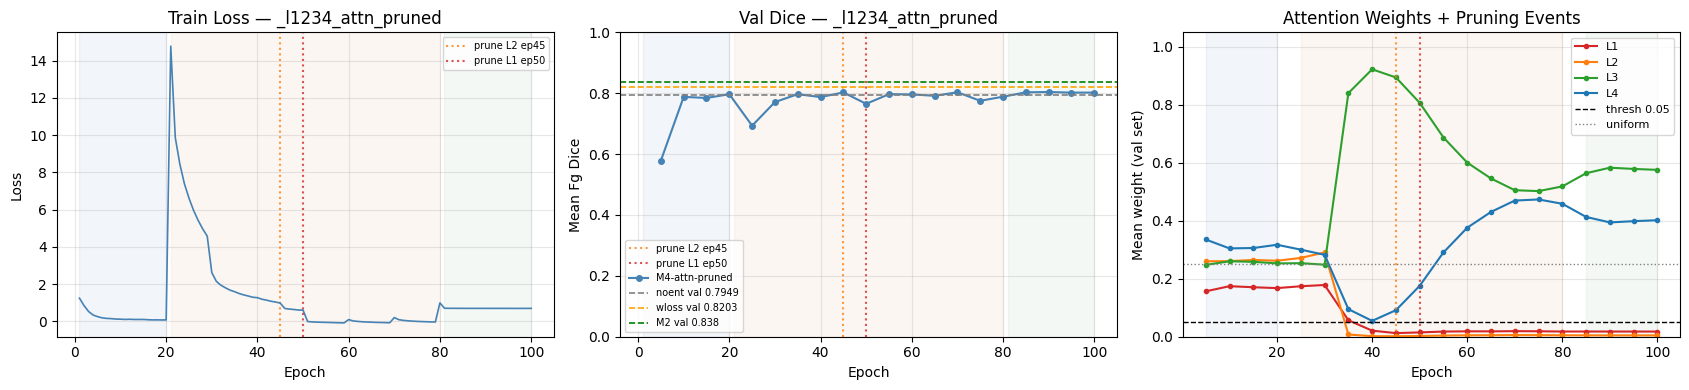


Pruning events:
 epoch  level  w_at_prune
    45      2     0.00166
    50      1     0.01493

Best val Dice: 0.8040


In [6]:
import pandas as pd

log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=["val_mean_fg_dice"])
attn = pd.read_csv(ATTN_LOG)
try:
    prune_log = pd.read_csv(PRUNE_LOG)
except Exception:
    prune_log = pd.DataFrame(columns=["epoch", "level", "w_at_prune"])

NOENT_VAL = 0.7949
WLOSS_VAL = 0.8203
M2_VAL = 0.8380
PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}
LEVEL_COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
PRUNE_COLORS = LEVEL_COLORS  # same order L1-L4

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax in axes[:2]:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ep = log.loc[mask, "epoch"]
            ax.axvspan(ep.min(), ep.max(), alpha=0.07, color=color)
    # Mark pruning events
    for _, row in prune_log.iterrows():
        ax.axvline(
            row["epoch"],
            color=LEVEL_COLORS[int(row["level"]) - 1],
            ls=":",
            lw=1.5,
            alpha=0.8,
            label=f"prune L{int(row['level'])} ep{int(row['epoch'])}",
        )

# Left: train loss
axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title=f"Train Loss — {SUFFIX}", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)

# Middle: val Dice vs baselines
axes[1].plot(
    val["epoch"],
    val["val_mean_fg_dice"],
    "o-",
    ms=4,
    lw=1.5,
    color="steelblue",
    label="M4-attn-pruned",
)
axes[1].axhline(
    NOENT_VAL, color="gray", ls="--", lw=1.2, label=f"noent val {NOENT_VAL}"
)
axes[1].axhline(
    WLOSS_VAL, color="orange", ls="--", lw=1.2, label=f"wloss val {WLOSS_VAL}"
)
axes[1].axhline(M2_VAL, color="green", ls="--", lw=1.2, label=f"M2 val {M2_VAL}")
axes[1].set(
    title=f"Val Dice — {SUFFIX}", xlabel="Epoch", ylabel="Mean Fg Dice", ylim=(0, 1.0)
)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=7)

# Right: attention weight evolution with pruning markers
ax = axes[2]
for ph, color in PHASE_COLORS.items():
    mask = attn["phase"] == ph
    if mask.any():
        ax.axvspan(
            attn.loc[mask, "epoch"].min(),
            attn.loc[mask, "epoch"].max(),
            alpha=0.07,
            color=color,
        )
for i, l in enumerate(PROTO_LEVELS):
    col = f"w_L{l}"
    if col in attn.columns:
        ax.plot(
            attn["epoch"],
            attn[col],
            "o-",
            ms=3,
            lw=1.5,
            color=LEVEL_COLORS[i],
            label=f"L{l}",
        )
for _, row in prune_log.iterrows():
    ax.axvline(
        row["epoch"],
        color=LEVEL_COLORS[int(row["level"]) - 1],
        ls=":",
        lw=1.5,
        alpha=0.8,
    )
ax.axhline(
    PRUNE_THRESHOLD, color="black", ls="--", lw=1, label=f"thresh {PRUNE_THRESHOLD}"
)
ax.axhline(0.25, color="gray", ls=":", lw=1, label="uniform")
ax.set(
    title="Attention Weights + Pruning Events",
    xlabel="Epoch",
    ylabel="Mean weight (val set)",
    ylim=(0, 1.05),
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/train_curve{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPruning events:")
print(prune_log.to_string(index=False) if not prune_log.empty else "  (none)")
print(f"\nBest val Dice: {val['val_mean_fg_dice'].max():.4f}")

## 6. Quick 3D Dice Eval

In [7]:
from src.data.mmwhs_dataset import MMWHSPatientDataset

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt["proto_levels"],
    use_level_attention=ckpt.get("use_level_attention", False),
).to(DEVICE)
eval_model.load_state_dict(ckpt["model_state_dict"])
# Restore pruned_levels so forward() behaves correctly at eval time
eval_model.pruned_levels = set(ckpt.get("pruned_levels", []))
eval_model.eval()
print(
    f"Loaded epoch {ckpt['epoch']}  best_val {ckpt['best_val_dice']:.4f}  "
    f"pruned_levels={eval_model.pruned_levels}"
)


@torch.no_grad()
def eval_3d(model, modality):
    ds = MMWHSPatientDataset(DATA_DIR, modality, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


results = eval_3d(eval_model, MODALITY)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

M4_3D = 0.8407
M4NOENT_3D = 0.8416
M4WLOSS_3D = 0.8475
M2_3D = 0.8722

print(f"\n3D Dice — {SUFFIX}")
print(f"{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")
overall = np.mean(all_means)
print("─" * 75)
print(f"{'Mean':<12} {overall:>7.4f}")
print(f"\nΔ vs M4-attn-noent ({M4NOENT_3D:.4f}): {overall - M4NOENT_3D:+.4f}")
print(f"Δ vs M4-attn-wloss ({M4WLOSS_3D:.4f}): {overall - M4WLOSS_3D:+.4f}")
print(f"Δ vs M2            ({M2_3D:.4f}): {overall - M2_3D:+.4f}")

print(f"\nRQ7 Dice criterion: ≥ 0.8600")
print("✅ passes" if overall >= 0.8600 else f"⚠️ {overall:.4f} < 0.8600")

Loaded epoch 90  best_val 0.8040  pruned_levels={1, 2}

3D Dice — _l1234_attn_pruned
Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7213  0.789  0.854  0.746  0.865  0.725  0.599  0.471
ct_1020       0.9186  0.871  0.960  0.930  0.890  0.910  0.968  0.901
───────────────────────────────────────────────────────────────────────────
Mean          0.8199

Δ vs M4-attn-noent (0.8416): -0.0217
Δ vs M4-attn-wloss (0.8475): -0.0276
Δ vs M2            (0.8722): -0.0523

RQ7 Dice criterion: ≥ 0.8600
⚠️ 0.8199 < 0.8600
